In [ ]:
import pandas as pd
import numpy as np
# Loading the dataset
df=pd.read_csv('/content/dataset.csv')

In [ ]:
# Dataset information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [ ]:
# Checking number of missing values in each column
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [ ]:
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

le = LabelEncoder()

In [ ]:
for column in df.select_dtypes(include='object').columns:
    df[column] = le.fit_transform(df[column])

In [ ]:
X = df.drop('Outcome', axis=1)
y = le.fit_transform(df['Outcome'])

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

le = LabelEncoder()

# Now split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# Now scaling
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
# Correlation matrix
corr=df.corr()
corr

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
Pregnancies,1.000000,0.129459,0.141282,-0.081672,-0.073535,0.017683,-0.033523,0.544341,0.221898
Glucose,0.129459,1.000000,0.152590,0.057328,0.331357,0.221071,0.137337,0.263514,0.466581
BloodPressure,0.141282,0.152590,1.000000,0.207371,0.088933,0.281805,0.041265,0.239528,0.065068
SkinThickness,-0.081672,0.057328,0.207371,1.000000,0.436783,0.392573,0.183928,-0.113970,0.074752
Insulin,-0.073535,0.331357,0.088933,0.436783,1.000000,0.197859,0.185071,-0.042163,0.130548
BMI,0.017683,0.221071,0.281805,0.392573,0.197859,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,-0.033523,0.137337,0.041265,0.183928,0.185071,0.140647,1.000000,0.033561,0.173844
Age,0.544341,0.263514,0.239528,-0.113970,-0.042163,0.036242,0.033561,1.000000,0.238356
Outcome,0.221898,0.466581,0.065068,0.074752,0.130548,0.292695,0.173844,0.238356,1.000000


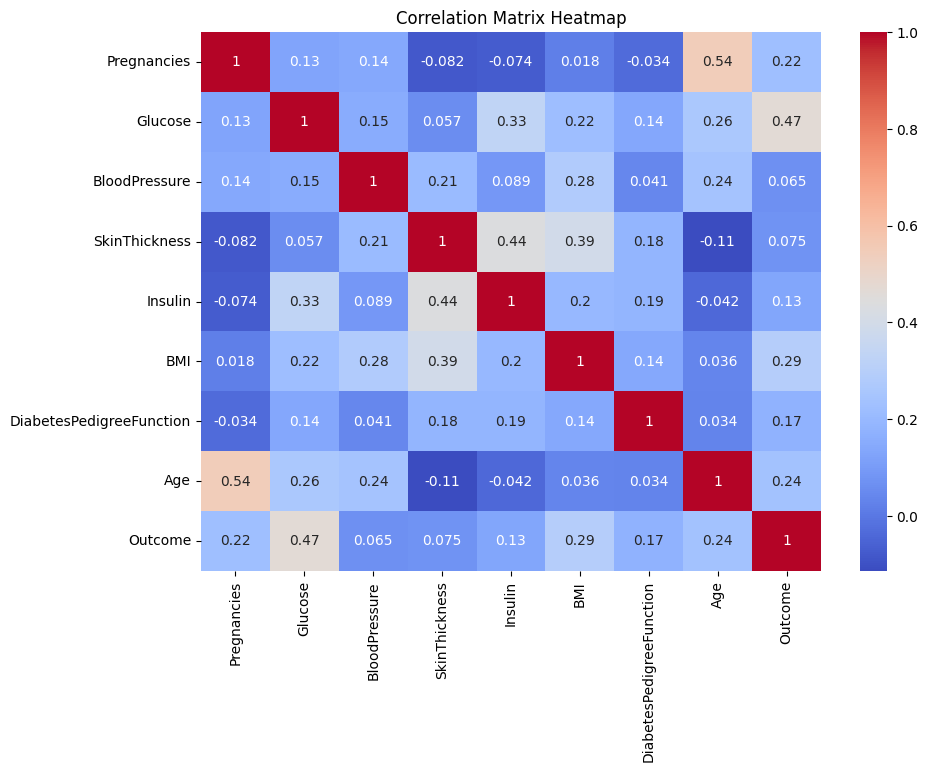

In [ ]:
# Correlation Heatmap
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10,7))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix Heatmap")
plt.show()

In [ ]:
# Work on models training
# logistic regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
lr=LogisticRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.7532467532467533
              precision    recall  f1-score   support

           0       0.81      0.80      0.81        99
           1       0.65      0.67      0.66        55

    accuracy                           0.75       154
   macro avg       0.73      0.74      0.73       154
weighted avg       0.76      0.75      0.75       154



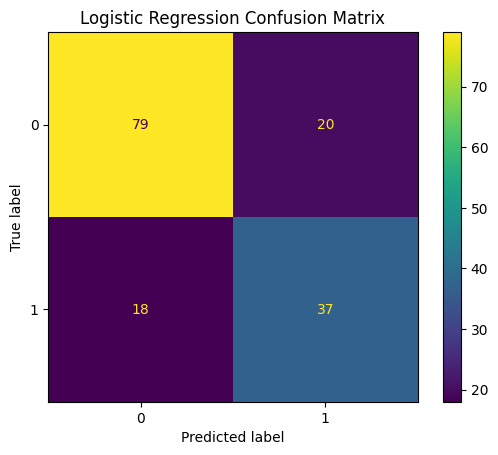

In [ ]:
#logistic regression confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

#Confusion matrix of Logistic Regression before applying hyperparameter tuning
cm_lr = confusion_matrix(y_test, y_pred_lr)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_lr)
disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [ ]:
#SVM
from sklearn.svm import SVC
svm = SVC(probability=True)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)

print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.7337662337662337
              precision    recall  f1-score   support

           0       0.77      0.83      0.80        99
           1       0.65      0.56      0.60        55

    accuracy                           0.73       154
   macro avg       0.71      0.70      0.70       154
weighted avg       0.73      0.73      0.73       154



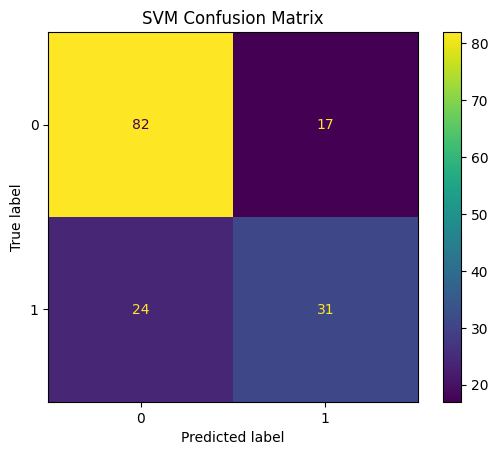

In [ ]:
#Confusion matrix of SVM before applying hyperparameter tuning
cm_svm = confusion_matrix(y_test, y_pred_svm)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_svm)
disp.plot()
plt.title("SVM Confusion Matrix")
plt.show()

In [ ]:
# KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)

print("KNN Accuracy:", accuracy_score(y_test, y_pred_knn))
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 0.6948051948051948
              precision    recall  f1-score   support

           0       0.75      0.80      0.77        99
           1       0.58      0.51      0.54        55

    accuracy                           0.69       154
   macro avg       0.66      0.65      0.66       154
weighted avg       0.69      0.69      0.69       154



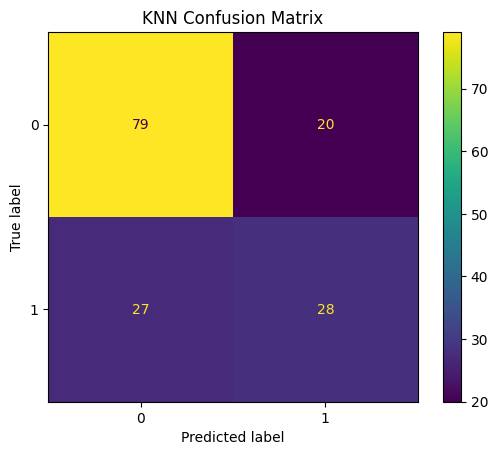

In [ ]:
#Confusion matrix of  KNN before applying hyperparameter tuning
cm_knn = confusion_matrix(y_test, y_pred_knn)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_knn)
disp.plot()
plt.title("KNN Confusion Matrix")
plt.show()

In [ ]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.7402597402597403
              precision    recall  f1-score   support

           0       0.80      0.80      0.80        99
           1       0.64      0.64      0.64        55

    accuracy                           0.74       154
   macro avg       0.72      0.72      0.72       154
weighted avg       0.74      0.74      0.74       154



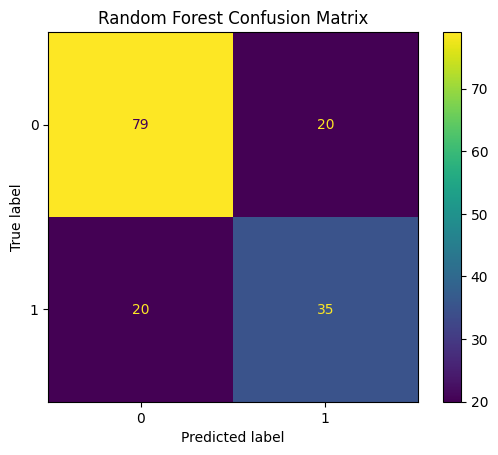

In [ ]:
#Confusion matrix of Random Forest Classifier before applying hyperparameter tuning
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)
disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

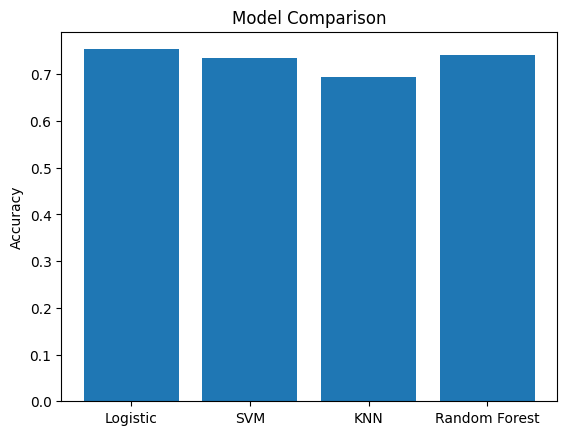

In [ ]:
# Accuracy comparasion
import matplotlib.pyplot as plt

models = ["Logistic", "SVM", "KNN", "Random Forest"]
scores = [
    accuracy_score(y_test, y_pred_lr),
    accuracy_score(y_test, y_pred_svm),
    accuracy_score(y_test, y_pred_knn),
    accuracy_score(y_test, y_pred_rf)
]

plt.bar(models, scores)
plt.title("Model Comparison")
plt.ylabel("Accuracy")
plt.show()

In [ ]:
# ROC Curve Before Hyperparameter Tuning
y_prob_lr = lr.predict_proba(X_test)[:,1]
y_prob_svm = svm.predict_proba(X_test)[:,1]
y_prob_knn = knn.predict_proba(X_test)[:,1]
y_prob_rf = rf.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_lr = auc(fpr_lr, tpr_lr)
auc_svm = auc(fpr_svm, tpr_svm)
auc_knn = auc(fpr_knn, tpr_knn)
auc_rf = auc(fpr_rf, tpr_rf)

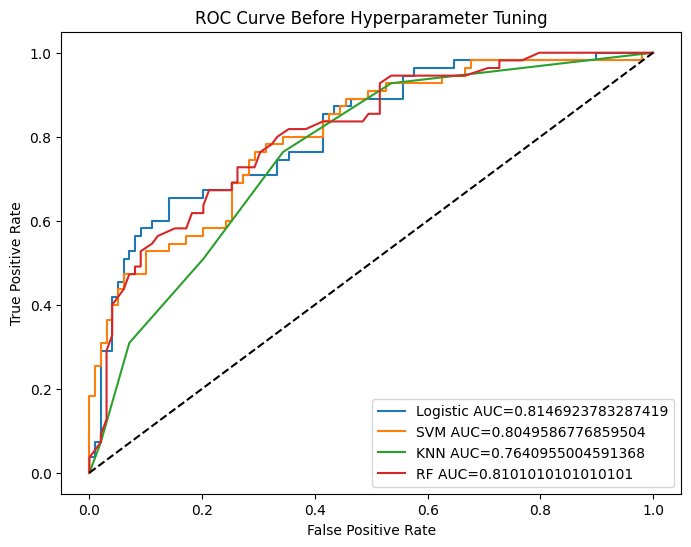

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label="Logistic AUC="+str(auc_lr))
plt.plot(fpr_svm, tpr_svm, label="SVM AUC="+str(auc_svm))
plt.plot(fpr_knn, tpr_knn, label="KNN AUC="+str(auc_knn))
plt.plot(fpr_rf, tpr_rf, label="RF AUC="+str(auc_rf))

plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Before Hyperparameter Tuning")
plt.legend()
plt.show()

In [ ]:
# using hyper parameters for tunning
from sklearn.model_selection import GridSearchCV
# Logistic Regression
lr_grid = GridSearchCV(LogisticRegression(), {'C':[0.1,1,10]}, cv=5)
lr_grid.fit(X_train, y_train)

# SVM
svm_grid = GridSearchCV(SVC(), {'C':[0.1,1], 'kernel':['Poly','rbf']}, cv=5)
svm_grid.fit(X_train, y_train)

# KNN
knn_grid = GridSearchCV(KNeighborsClassifier(), {'n_neighbors':[3,5,7]}, cv=5)
knn_grid.fit(X_train, y_train)

# Random Forest
rf_grid = GridSearchCV(RandomForestClassifier(), {'n_estimators':[50,100]}, cv=5)
rf_grid.fit(X_train, y_train)

print("Best LR:", lr_grid.best_params_)
print("Best SVM:", svm_grid.best_params_)
print("Best KNN:", knn_grid.best_params_)
print("Best RF:", rf_grid.best_params_)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py:528: FitFailedWarning: 
10 fits failed out of a total of 20.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
10 fits failed with the following error:
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 1382, in wrapper
    estimator._validate_params()
  File "/usr/local/lib/python3.12/dist-packages/sklearn/base.py", line 436, in _validate_params
    validate_parameter_constraints(
  File "/usr/local/lib/python3.12/dist-packages/sklearn/utils/_

Best LR: {'C': 10}
Best SVM: {'C': 1, 'kernel': 'rbf'}
Best KNN: {'n_neighbors': 5}
Best RF: {'n_estimators': 100}


In [ ]:
best_lr = lr_grid.best_estimator_
best_svm = svm_grid.best_estimator_
best_knn = knn_grid.best_estimator_
best_rf = rf_grid.best_estimator_

In [ ]:
y_pred_lr = best_lr.predict(X_test)
y_pred_svm = best_svm.predict(X_test)
y_pred_knn = best_knn.predict(X_test)
y_pred_rf = best_rf.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

models = {
    "Logistic Regression": y_pred_lr,
    "SVM": y_pred_svm,
    "KNN": y_pred_knn,
    "Random Forest": y_pred_rf
}

for name, pred in models.items():
    print(f"\n{name}")
    print("Best Parameters:",
          lr_grid.best_params_ if name=="Logistic Regression" else
          svm_grid.best_params_ if name=="SVM" else
          knn_grid.best_params_ if name=="KNN" else
          rf_grid.best_params_)

    print("Accuracy :", accuracy_score(y_test, pred))
    print("Precision:", precision_score(y_test, pred))
    print("Recall   :", recall_score(y_test, pred))
    print("F1 Score :", f1_score(y_test, pred))


Logistic Regression
Best Parameters: {'C': 10}
Accuracy : 0.7532467532467533
Precision: 0.6491228070175439
Recall   : 0.6727272727272727
F1 Score : 0.6607142857142857

SVM
Best Parameters: {'C': 1, 'kernel': 'rbf'}
Accuracy : 0.7337662337662337
Precision: 0.6458333333333334
Recall   : 0.5636363636363636
F1 Score : 0.6019417475728155

KNN
Best Parameters: {'n_neighbors': 5}
Accuracy : 0.6948051948051948
Precision: 0.5833333333333334
Recall   : 0.509090909090909
F1 Score : 0.5436893203883495

Random Forest
Best Parameters: {'n_estimators': 100}
Accuracy : 0.7402597402597403
Precision: 0.631578947368421
Recall   : 0.6545454545454545
F1 Score : 0.6428571428571429


In [ ]:
svm_grid = GridSearchCV(
    SVC(probability=True),
    {'C': [0.1, 1], 'kernel': ['linear', 'rbf']},
    cv=5
)
svm_grid.fit(X_train, y_train)

best_svm = svm_grid.best_estimator_

In [ ]:
# Logistic Regression
y_prob_lr = best_lr.predict_proba(X_test)[:,1]

# SVM
y_prob_svm = best_svm.predict_proba(X_test)[:,1]

# KNN
y_prob_knn = best_knn.predict_proba(X_test)[:,1]

# Random Forest
y_prob_rf = best_rf.predict_proba(X_test)[:,1]

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_prob_knn)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

auc_lr = auc(fpr_lr, tpr_lr)
auc_svm = auc(fpr_svm, tpr_svm)
auc_knn = auc(fpr_knn, tpr_knn)
auc_rf = auc(fpr_rf, tpr_rf)

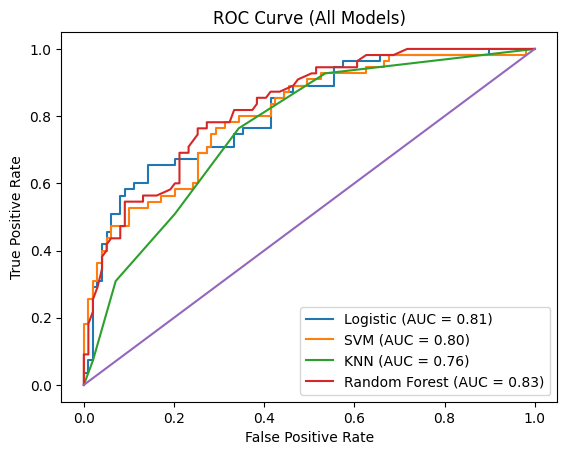

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

plt.plot(fpr_lr, tpr_lr, label=f"Logistic (AUC = {auc_lr:.2f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.2f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {auc_knn:.2f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.2f})")

# Diagonal line
plt.plot([0,1], [0,1])

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (All Models)")
plt.legend()

plt.show()

Logistic Regression
Best Parameters: {'C': 10}
Accuracy : 0.7532467532467533
Precision: 0.6491228070175439
Recall   : 0.6727272727272727
F1 Score : 0.6607142857142857
Confusion Matrix:
 [[79 20]
 [18 37]]


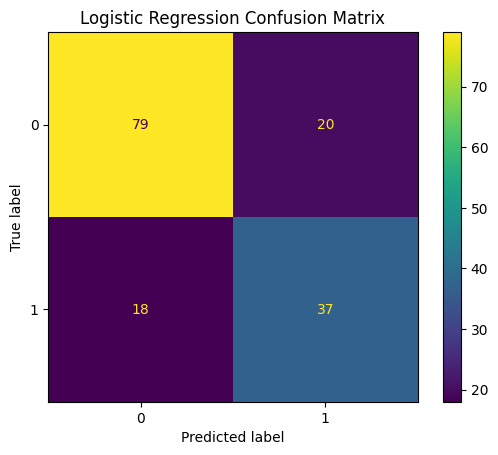

In [ ]:
best_lr = lr_grid.best_estimator_

y_pred_lr = best_lr.predict(X_test)

print("Logistic Regression")
print("Best Parameters:", lr_grid.best_params_)
print("Accuracy :", accuracy_score(y_test, y_pred_lr))
print("Precision:", precision_score(y_test, y_pred_lr))
print("Recall   :", recall_score(y_test, y_pred_lr))
print("F1 Score :", f1_score(y_test, y_pred_lr))

# Confusion Matrix
cm_lr = confusion_matrix(y_test, y_pred_lr)
print("Confusion Matrix:\n", cm_lr)

ConfusionMatrixDisplay(cm_lr).plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

SVM
Best Parameters: {'C': 1, 'kernel': 'rbf'}
Accuracy : 0.7337662337662337
Precision: 0.6458333333333334
Recall   : 0.5636363636363636
F1 Score : 0.6019417475728155
Confusion Matrix:
 [[82 17]
 [24 31]]


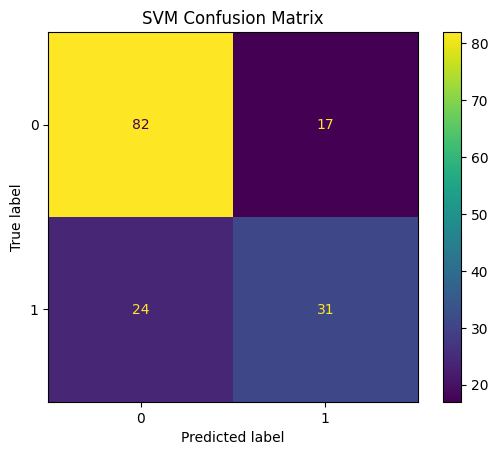

In [ ]:
best_svm = svm_grid.best_estimator_

y_pred_svm = best_svm.predict(X_test)

print("SVM")
print("Best Parameters:", svm_grid.best_params_)
print("Accuracy :", accuracy_score(y_test, y_pred_svm))
print("Precision:", precision_score(y_test, y_pred_svm))
print("Recall   :", recall_score(y_test, y_pred_svm))
print("F1 Score :", f1_score(y_test, y_pred_svm))

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
print("Confusion Matrix:\n", cm_svm)

ConfusionMatrixDisplay(cm_svm).plot()
plt.title("SVM Confusion Matrix")
plt.show()

KNN
Best Parameters: {'n_neighbors': 5}
Accuracy : 0.6948051948051948
Precision: 0.5833333333333334
Recall   : 0.509090909090909
F1 Score : 0.5436893203883495
Confusion Matrix:
 [[79 20]
 [27 28]]


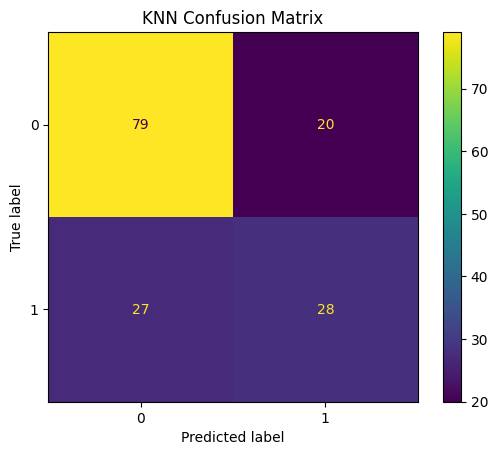

In [ ]:
best_knn = knn_grid.best_estimator_

y_pred_knn = best_knn.predict(X_test)

print("KNN")
print("Best Parameters:", knn_grid.best_params_)
print("Accuracy :", accuracy_score(y_test, y_pred_knn))
print("Precision:", precision_score(y_test, y_pred_knn))
print("Recall   :", recall_score(y_test, y_pred_knn))
print("F1 Score :", f1_score(y_test, y_pred_knn))

# Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
print("Confusion Matrix:\n", cm_knn)

ConfusionMatrixDisplay(cm_knn).plot()
plt.title("KNN Confusion Matrix")
plt.show()

Random Forest
Best Parameters: {'n_estimators': 100}
Accuracy : 0.7402597402597403
Precision: 0.631578947368421
Recall   : 0.6545454545454545
F1 Score : 0.6428571428571429
Confusion Matrix:
 [[78 21]
 [19 36]]


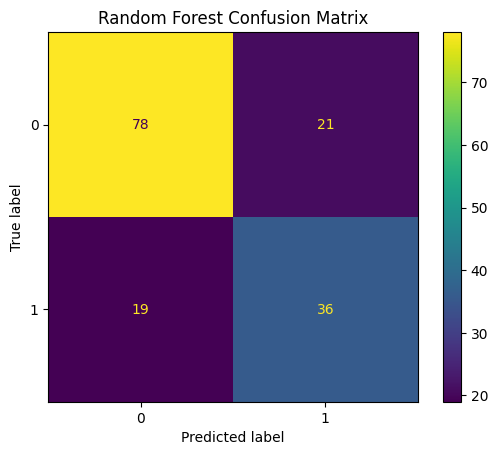

In [ ]:
best_rf = rf_grid.best_estimator_

y_pred_rf = best_rf.predict(X_test)

print("Random Forest")
print("Best Parameters:", rf_grid.best_params_)
print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)
print("Confusion Matrix:\n", cm_rf)

ConfusionMatrixDisplay(cm_rf).plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

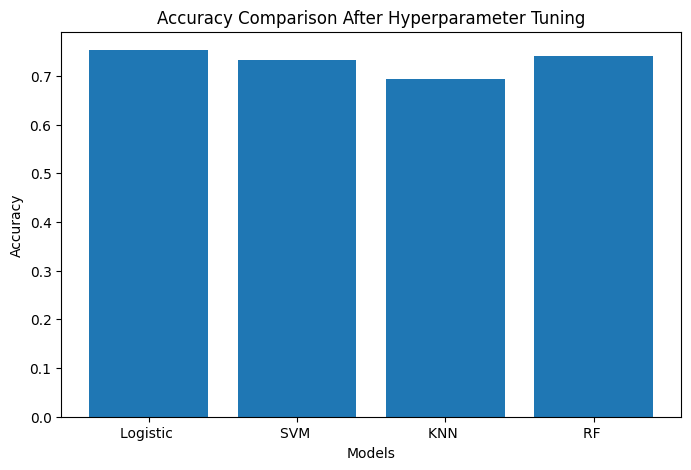

In [ ]:
#Accuracy Comparison After Hyperparameter Tuning
y_pred_lr_tuned = lr_grid.best_estimator_.predict(X_test)
y_pred_svm_tuned = svm_grid.best_estimator_.predict(X_test)
y_pred_knn_tuned = knn_grid.best_estimator_.predict(X_test)
y_pred_rf_tuned = rf_grid.best_estimator_.predict(X_test)

import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

models = ["Logistic ", "SVM ", "KNN ", "RF "]

scores = [
    accuracy_score(y_test, y_pred_lr_tuned),
    accuracy_score(y_test, y_pred_svm_tuned),
    accuracy_score(y_test, y_pred_knn_tuned),
    accuracy_score(y_test, y_pred_rf_tuned)
]

plt.figure(figsize=(8,5))
plt.bar(models, scores)
plt.title("Accuracy Comparison After Hyperparameter Tuning")
plt.ylabel("Accuracy")
plt.xlabel("Models")
plt.show()